# Cell 1

In [1]:
import torch
import numpy as np
import os

# Verify GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device         : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    print("✅ GPU confirmed — training will be fast")
else:
    print("⚠️ No GPU — go to Settings → Accelerator → GPU P100")

Device         : cuda
GPU name       : Tesla T4
GPU memory     : 15.6 GB
✅ GPU confirmed — training will be fast


# Cell 2

In [2]:
import pickle
import json

# ── Paths ─────────────────────────────────────────────────
INPUT_PATH  = "/kaggle/input/datasets/abhijeetckarve/phd-maml-ae-data"
OUTPUT_PATH = "/kaggle/working"

os.makedirs(f"{OUTPUT_PATH}/models/checkpoints", exist_ok=True)
os.makedirs(f"{OUTPUT_PATH}/results/figures",    exist_ok=True)

# ── Load preprocessed data ─────────────────────────────────
print("Loading data...")
with open(f"{INPUT_PATH}/channel_data_normalized.pkl", "rb") as f:
    channel_data = pickle.load(f)

with open(f"{INPUT_PATH}/task_splits_25feat.json", "r") as f:
    task_splits_25 = json.load(f)

with open(f"{INPUT_PATH}/config.json", "r") as f:
    config = json.load(f)

# ── Task splits — 25-feature SMAP channels only ────────────
meta_train_tasks = task_splits_25['meta_train']
meta_val_tasks   = task_splits_25['meta_val']
meta_test_25     = task_splits_25['meta_test']

print(f"✅ Data loaded successfully")
print(f"Total channels loaded  : {len(channel_data)}")
print(f"Meta-train tasks       : {len(meta_train_tasks)}")
print(f"Meta-val tasks         : {len(meta_val_tasks)}")
print(f"Meta-test tasks        : {len(meta_test_25)}")
print(f"\nMeta-test channels     : {meta_test_25}")

Loading data...
✅ Data loaded successfully
Total channels loaded  : 81
Meta-train tasks       : 39
Meta-val tasks         : 6
Meta-test tasks        : 9

Meta-test channels     : ['E-3', 'D-7', 'E-6', 'D-12', 'D-6', 'T-2', 'A-6', 'D-3', 'P-4']


# Cell 3

In [3]:
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)


class LSTMEncoder(nn.Module):
    """
    Compresses a sensor window (30 timesteps × 25 sensors)
    down to a 16-number bottleneck code.
    """
    def __init__(self, input_size=25, hidden1=64,
                 hidden2=32, latent=16):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1,
                             batch_first=True)
        self.lstm2 = nn.LSTM(hidden1,   hidden2,
                             batch_first=True)
        self.fc    = nn.Linear(hidden2, latent)

    def forward(self, x):
        # x: (batch, 30, 25)
        out,  _     = self.lstm1(x)
        _, (h_n, _) = self.lstm2(out)
        h_n         = h_n.squeeze(0)
        return self.fc(h_n)
        # returns: (batch, 16)


class LSTMDecoder(nn.Module):
    """
    Reconstructs the original sensor window from
    the 16-number bottleneck code.
    """
    def __init__(self, latent=16, hidden1=32,
                 hidden2=64, output_size=25, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.lstm1   = nn.LSTM(latent,  hidden1,
                               batch_first=True)
        self.lstm2   = nn.LSTM(hidden1, hidden2,
                               batch_first=True)
        self.fc      = nn.Linear(hidden2, output_size)

    def forward(self, z):
        # z: (batch, 16)
        z_rep      = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _     = self.lstm1(z_rep)
        out, _     = self.lstm2(out)
        return self.fc(out)
        # returns: (batch, 30, 25)


class LSTMAutoencoder(nn.Module):
    """
    Full anomaly detector.
    Train on normal data only.
    High reconstruction error = anomaly.
    """
    def __init__(self, input_size=25, seq_len=30,
                 hidden1=64, hidden2=32, latent=16):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden1,
                                   hidden2, latent)
        self.decoder = LSTMDecoder(latent, hidden2,
                                   hidden1, input_size,
                                   seq_len)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        """
        Returns one anomaly score per window.
        Higher score = more anomalous.
        """
        x_hat = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=(1, 2))


# ── Build model and load clean initialization ──────────────
model = LSTMAutoencoder(
    input_size = 25,
    seq_len    = 30,
    hidden1    = 64,
    hidden2    = 32,
    latent     = 16
).to(DEVICE)

checkpoint = torch.load(
    f"{INPUT_PATH}/lstm_ae_init.pt",
    map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])

total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)

print(f"LSTM Autoencoder built and initialized")
print(f"Total trainable parameters : {total_params:,}")
print(f"Device                     : {DEVICE}")
print(f"✅ Model ready")

LSTM Autoencoder built and initialized
Total trainable parameters : 69,481
Device                     : cuda
✅ Model ready


# Cell 4

In [4]:
import copy

# ── Hyperparameters ───────────────────────────────────────
INNER_LR         = 0.01    # inner loop learning rate
OUTER_LR         = 0.001   # outer loop learning rate
INNER_STEPS      = 10       # gradient steps per task
TASKS_PER_BATCH  = 4       # tasks per outer update
SUPPORT_SIZE     = 20      # normal windows for adaptation
QUERY_SIZE       = 20      # normal windows for meta-loss

# ── Loss and Optimizer ────────────────────────────────────
criterion       = nn.MSELoss()
outer_optimizer = torch.optim.Adam(
    model.parameters(), lr=OUTER_LR)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    outer_optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-5
)


# ── Manual MAML Inner Loop ────────────────────────────────
def maml_inner_loop(model, support, criterion,
                    inner_lr=0.01, inner_steps=5):
    """
    Adapts a CLONE of the model to the support set.

    The original model θ* is never modified here.
    Only the deep copy (learner) is updated.
    This is the K-step inner loop of MAML.

    Args:
        model      : the meta-initialized model θ*
        support    : normal windows tensor (support_size, 30, 25)
        criterion  : MSE loss function
        inner_lr   : learning rate for inner loop SGD
        inner_steps: number of gradient steps

    Returns:
        learner    : adapted model θ' for this task
    """
    learner         = copy.deepcopy(model)
    learner.train()
    inner_optimizer = torch.optim.SGD(
        learner.parameters(), lr=inner_lr)

    for _ in range(inner_steps):
        inner_optimizer.zero_grad()
        recon = learner(support)
        loss  = criterion(recon, support)
        loss.backward()
        inner_optimizer.step()

    return learner


# ── Manual MAML Outer Step ────────────────────────────────
def maml_outer_step(model, outer_optimizer, criterion,
                    task_batch, channel_data,
                    inner_lr=0.01, inner_steps=5,
                    support_size=20, query_size=20,
                    train=True):
    """
    One complete outer loop step of MAML.

    For each task in task_batch:
      1. Clone model → adapt on support set (inner loop) → θ'
      2. Compute reconstruction loss on query set using θ'

    Average query losses across tasks → meta-loss
    If train=True: backpropagate meta-loss → update θ*

    Args:
        model           : meta-initialized model θ*
        outer_optimizer : Adam optimizer for θ*
        criterion       : MSE loss function
        task_batch      : list of channel IDs for this step
        channel_data    : preprocessed channel windows dict
        inner_lr        : inner loop learning rate
        inner_steps     : inner loop gradient steps
        support_size    : normal windows in support set
        query_size      : normal windows in query set
        train           : if True update θ*, if False just evaluate

    Returns:
        meta_loss.item(): float — average query loss
    """
    meta_loss = torch.tensor(0.0)

    for channel_id in task_batch:
        # Sample episode for this task
        support, query = sample_meta_train_episode(
            channel_id, support_size, query_size)

        # Inner loop — adapt clone to this channel
        learner = maml_inner_loop(
            model, support, criterion,
            inner_lr, inner_steps)

        # Query loss — reconstruction after adaptation
        learner.train()
        query_recon = learner(query)
        query_loss  = criterion(query_recon, query)
        meta_loss   = meta_loss + query_loss

    # Average across tasks
    meta_loss = meta_loss / len(task_batch)

    # Outer loop update
    if train:
        outer_optimizer.zero_grad()
        meta_loss.backward()
        # Gradient clipping — prevents LSTM exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0)
        outer_optimizer.step()

    return meta_loss.item()


print("Manual MAML Configuration")
print("=" * 45)
print(f"Inner LR (α)         : {INNER_LR}")
print(f"Outer LR (β)         : {OUTER_LR}")
print(f"Inner steps          : {INNER_STEPS}")
print(f"Tasks per batch      : {TASKS_PER_BATCH}")
print(f"Support size         : {SUPPORT_SIZE} normal windows")
print(f"Query size           : {QUERY_SIZE} normal windows")
print(f"\n✅ Manual MAML ready — no learn2learn needed")

Manual MAML Configuration
Inner LR (α)         : 0.01
Outer LR (β)         : 0.001
Inner steps          : 10
Tasks per batch      : 4
Support size         : 20 normal windows
Query size           : 20 normal windows

✅ Manual MAML ready — no learn2learn needed


# Cell 5

In [5]:
def sample_meta_train_episode(channel_id,
                               support_size=20,
                               query_size=20):
    """
    Samples one meta-training episode from a channel.

    Both support and query sets use NORMAL windows only.
    This is correct for reconstruction-based anomaly detection:
      - Support: model adapts to this channel's normal patterns
      - Query  : meta-loss measures reconstruction after adaptation

    Anomaly windows are NEVER used during meta-training.
    They are reserved entirely for Notebook 5 evaluation.

    Args:
        channel_id   : which channel to sample from
        support_size : number of normal windows in support set
        query_size   : number of normal windows in query set

    Returns:
        support_tensor : (support_size, 30, 25) on DEVICE
        query_tensor   : (query_size,   30, 25) on DEVICE
    """
    normal_wins = channel_data[channel_id]['normal_windows'].copy()
    np.random.shuffle(normal_wins)

    needed = support_size + query_size

    if len(normal_wins) < needed:
        # Not enough windows — sample with replacement
        support_idx = np.random.choice(
            len(normal_wins), support_size, replace=True)
        query_idx   = np.random.choice(
            len(normal_wins), query_size, replace=True)
        support = normal_wins[support_idx]
        query   = normal_wins[query_idx]
    else:
        support = normal_wins[:support_size]
        query   = normal_wins[support_size:support_size + query_size]

    support_tensor = torch.tensor(
        support, dtype=torch.float32).to(DEVICE)
    query_tensor   = torch.tensor(
        query, dtype=torch.float32).to(DEVICE)

    return support_tensor, query_tensor


# Test the sampler
test_ch = meta_train_tasks[0]
s, q    = sample_meta_train_episode(test_ch)

print(f"Episode sampler test — channel : {test_ch}")
print(f"Support set shape : {s.shape}")
print(f"  = {s.shape[0]} normal windows × "
      f"{s.shape[1]} timesteps × {s.shape[2]} sensors")
print(f"Query set shape   : {q.shape}")
print(f"Device            : {s.device}")
print(f"\n✅ Episode sampler working correctly")

Episode sampler test — channel : P-3
Support set shape : torch.Size([20, 30, 25])
  = 20 normal windows × 30 timesteps × 25 sensors
Query set shape   : torch.Size([20, 30, 25])
Device            : cuda:0

✅ Episode sampler working correctly


# Cell 6

In [6]:






import time

# ── Training Configuration ────────────────────────────────
N_OUTER_STEPS = 30000
VAL_EVERY     = 500     # validate every 100 steps
PRINT_EVERY   = 500     # print every 100 steps

train_losses  = []
val_losses    = []
val_steps     = []
best_val      = float('inf')
best_step     = 0

print("Starting MAML Training — Manual FOMAML")
print("=" * 55)
print(f"Outer steps          : {N_OUTER_STEPS}")
print(f"Tasks per batch      : {TASKS_PER_BATCH}")
print(f"Inner steps          : {INNER_STEPS}")
print(f"Validate every       : {VAL_EVERY} steps")
print(f"Meta-train tasks     : {len(meta_train_tasks)}")
print(f"Meta-val tasks       : {len(meta_val_tasks)}")
print(f"Device               : {DEVICE}")
print("=" * 55)

start_time = time.time()

for step in range(1, N_OUTER_STEPS + 1):

    # Sample random task batch
    task_batch = np.random.choice(
        meta_train_tasks,
        size    = TASKS_PER_BATCH,
        replace = False
    ).tolist()

    # One outer step
    model.train()
    train_loss = maml_outer_step(
        model, outer_optimizer, criterion,
        task_batch, channel_data,
        inner_lr     = INNER_LR,
        inner_steps  = INNER_STEPS,
        support_size = SUPPORT_SIZE,
        query_size   = QUERY_SIZE,
        train        = True
    )
    train_losses.append(train_loss)

    # Print progress
    if step % PRINT_EVERY == 0:
        elapsed = time.time() - start_time
        eta     = (elapsed / step) * (N_OUTER_STEPS - step)
        print(f"Step {step:5d}/{N_OUTER_STEPS} | "
              f"Train Loss: {train_loss:.6f} | "
              f"Elapsed: {elapsed:.0f}s | "
              f"ETA: {eta:.0f}s")

    # Validation every VAL_EVERY steps
    if step % VAL_EVERY == 0:
        val_loss_total = 0.0

        for val_ch in meta_val_tasks:
            v_loss = maml_outer_step(
                model, outer_optimizer, criterion,
                [val_ch], channel_data,
                inner_lr     = INNER_LR,
                inner_steps  = INNER_STEPS,
                support_size = SUPPORT_SIZE,
                query_size   = QUERY_SIZE,
                train        = False
            )
            val_loss_total += v_loss

        avg_val = val_loss_total / len(meta_val_tasks)
        scheduler.step(avg_val)
        val_losses.append(avg_val)
        val_steps.append(step)

        # Save best model
        if avg_val < best_val:
            best_val  = avg_val
            best_step = step
            torch.save({
                'step'             : step,
                'model_state_dict' : model.state_dict(),
                'val_loss'         : avg_val,
                'hyperparameters'  : {
                    'inner_lr'         : INNER_LR,
                    'outer_lr'         : OUTER_LR,
                    'inner_steps'      : INNER_STEPS,
                    'tasks_per_batch'  : TASKS_PER_BATCH,
                    'support_size'     : SUPPORT_SIZE,
                    'query_size'       : QUERY_SIZE,
                    'first_order'      : True,
                    'n_outer_steps'    : N_OUTER_STEPS,
                }
            }, f"{OUTPUT_PATH}/models/checkpoints/maml_best_kaggle.pt")
            print(f"  ✅ Best model saved — "
                  f"val loss: {avg_val:.6f} at step {step}")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time:.0f}s "
      f"({total_time/60:.1f} minutes)")
print(f"Best validation loss : {best_val:.6f} at step {best_step}")

Starting MAML Training — Manual FOMAML
Outer steps          : 30000
Tasks per batch      : 4
Inner steps          : 10
Validate every       : 500 steps
Meta-train tasks     : 39
Meta-val tasks       : 6
Device               : cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


Step   500/30000 | Train Loss: 0.025772 | Elapsed: 121s | ETA: 7140s
  ✅ Best model saved — val loss: 0.026449 at step 500
Step  1000/30000 | Train Loss: 0.016027 | Elapsed: 240s | ETA: 6964s
  ✅ Best model saved — val loss: 0.024465 at step 1000
Step  1500/30000 | Train Loss: 0.015537 | Elapsed: 359s | ETA: 6830s
Step  2000/30000 | Train Loss: 0.026916 | Elapsed: 479s | ETA: 6703s
Step  2500/30000 | Train Loss: 0.013349 | Elapsed: 598s | ETA: 6578s
Step  3000/30000 | Train Loss: 0.029970 | Elapsed: 718s | ETA: 6459s
Step  3500/30000 | Train Loss: 0.033754 | Elapsed: 837s | ETA: 6339s
  ✅ Best model saved — val loss: 0.023851 at step 3500
Step  4000/30000 | Train Loss: 0.021892 | Elapsed: 957s | ETA: 6218s
Step  4500/30000 | Train Loss: 0.028666 | Elapsed: 1076s | ETA: 6100s
Step  5000/30000 | Train Loss: 0.022294 | Elapsed: 1196s | ETA: 5981s
Step  5500/30000 | Train Loss: 0.026350 | Elapsed: 1316s | ETA: 5862s
  ✅ Best model saved — val loss: 0.021834 at step 5500
Step  6000/30000 | 

# Checking

In [7]:
# Check validation loss history
print("Validation loss history:")
print("=" * 40)
for step, val in zip(val_steps, val_losses):
    marker = " ← best" if val == best_val else ""
    print(f"  Step {step:6d} | val loss: {val:.6f}{marker}")

print(f"\nBest validation loss : {best_val:.6f} at step {best_step}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Improvement from best to final: "
      f"{((val_losses[-1]-best_val)/best_val*100):.1f}%")

Validation loss history:
  Step    500 | val loss: 0.026449
  Step   1000 | val loss: 0.024465
  Step   1500 | val loss: 0.025130
  Step   2000 | val loss: 0.025071
  Step   2500 | val loss: 0.026840
  Step   3000 | val loss: 0.024895
  Step   3500 | val loss: 0.023851
  Step   4000 | val loss: 0.024500
  Step   4500 | val loss: 0.026090
  Step   5000 | val loss: 0.025674
  Step   5500 | val loss: 0.021834 ← best
  Step   6000 | val loss: 0.027984
  Step   6500 | val loss: 0.022496
  Step   7000 | val loss: 0.024905
  Step   7500 | val loss: 0.022801
  Step   8000 | val loss: 0.023655
  Step   8500 | val loss: 0.024749
  Step   9000 | val loss: 0.027062
  Step   9500 | val loss: 0.026094
  Step  10000 | val loss: 0.027755
  Step  10500 | val loss: 0.024984
  Step  11000 | val loss: 0.024759
  Step  11500 | val loss: 0.027703
  Step  12000 | val loss: 0.027908
  Step  12500 | val loss: 0.024510
  Step  13000 | val loss: 0.026707
  Step  13500 | val loss: 0.024282
  Step  14000 | val los

# Cell 7

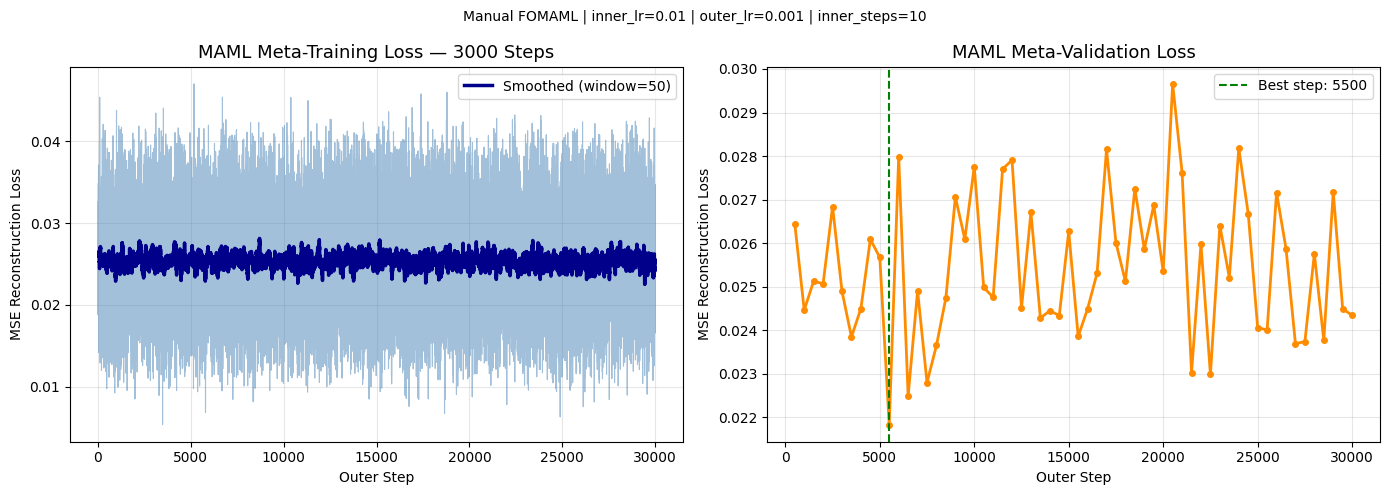

✅ Training curves saved


In [8]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Training loss
axes[0].plot(range(1, len(train_losses)+1), train_losses,
             color='steelblue', linewidth=0.8, alpha=0.5)

# Smoothed trend line
window   = 50
smoothed = np.convolve(train_losses,
                       np.ones(window)/window, mode='valid')
axes[0].plot(range(window, len(train_losses)+1), smoothed,
             color='darkblue', linewidth=2.5,
             label=f'Smoothed (window={window})')
axes[0].set_title("MAML Meta-Training Loss — 3000 Steps",
                  fontsize=13)
axes[0].set_xlabel("Outer Step")
axes[0].set_ylabel("MSE Reconstruction Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Validation loss
if val_losses:
    axes[1].plot(val_steps, val_losses,
                 color='darkorange', linewidth=2,
                 marker='o', markersize=4)
    axes[1].axvline(x=best_step, color='green',
                    linestyle='--', linewidth=1.5,
                    label=f'Best step: {best_step}')
    axes[1].set_title("MAML Meta-Validation Loss",
                      fontsize=13)
    axes[1].set_xlabel("Outer Step")
    axes[1].set_ylabel("MSE Reconstruction Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f"Manual FOMAML | inner_lr={INNER_LR} | "
    f"outer_lr={OUTER_LR} | inner_steps={INNER_STEPS}",
    fontsize=10)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/results/figures/"
            f"maml_training_curves_3000.png", dpi=150)
plt.show()
print("✅ Training curves saved")

# Cell 8

In [9]:
# Load best model
checkpoint = torch.load(
    f"{OUTPUT_PATH}/models/checkpoints/maml_best_kaggle.pt",
    map_location=DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])

print(f"Best model loaded")
print(f"  Saved at step    : {checkpoint['step']}")
print(f"  Validation loss  : {checkpoint['val_loss']:.6f}")
print(f"  Hyperparameters  : {checkpoint['hyperparameters']}")

# Quick check on first meta-test channel
print(f"\nQuick sanity check on one META-TEST channel...")
print(f"(Never seen during training)")

test_ch      = meta_test_25[0]
normal_wins  = channel_data[test_ch]['normal_windows']
anomaly_wins = channel_data[test_ch]['anomaly_windows']

support = torch.tensor(
    normal_wins[:SUPPORT_SIZE],
    dtype=torch.float32).to(DEVICE)
normal_query  = torch.tensor(
    normal_wins[SUPPORT_SIZE:SUPPORT_SIZE+30],
    dtype=torch.float32).to(DEVICE)
anomaly_query = torch.tensor(
    anomaly_wins[:30],
    dtype=torch.float32).to(DEVICE)

# Adapt using manual inner loop
learner = maml_inner_loop(
    model, support, criterion,
    inner_lr    = INNER_LR,
    inner_steps = INNER_STEPS
)

# Measure separation
learner.eval()
with torch.no_grad():
    n_scores = learner.reconstruction_error(normal_query)
    a_scores = learner.reconstruction_error(anomaly_query)

n_mean = n_scores.mean().item()
a_mean = a_scores.mean().item()
ratio  = a_mean / n_mean if n_mean > 0 else 0

print(f"Channel : {test_ch}")
print(f"  Normal  reconstruction error : {n_mean:.5f}")
print(f"  Anomaly reconstruction error : {a_mean:.5f}")
print(f"  Separation ratio             : {ratio:.2f}x")

if ratio > 1.5:
    print(f"\n✅ Strong separation — 3000-step training successful")
elif ratio > 1.0:
    print(f"\n✅ Positive separation — training working")
else:
    print(f"\n⚠️ Below 1.0 on this channel — run full diagnostic")

Best model loaded
  Saved at step    : 5500
  Validation loss  : 0.021834
  Hyperparameters  : {'inner_lr': 0.01, 'outer_lr': 0.001, 'inner_steps': 10, 'tasks_per_batch': 4, 'support_size': 20, 'query_size': 20, 'first_order': True, 'n_outer_steps': 30000}

Quick sanity check on one META-TEST channel...
(Never seen during training)
Channel : E-3
  Normal  reconstruction error : 0.03798
  Anomaly reconstruction error : 0.04371
  Separation ratio             : 1.15x

✅ Positive separation — training working


# Cell 9

In [10]:
print("Checking separation ratio across ALL meta-test channels")
print("=" * 55)

test_results = {}

for test_ch in meta_test_25:
    try:
        normal_wins  = channel_data[test_ch]['normal_windows']
        anomaly_wins = channel_data[test_ch]['anomaly_windows']

        # Skip if insufficient windows
        if len(normal_wins) < SUPPORT_SIZE + 10:
            print(f"  {test_ch:6s}: skipped — "
                  f"insufficient normal windows ({len(normal_wins)})")
            continue
        if len(anomaly_wins) < 5:
            print(f"  {test_ch:6s}: skipped — "
                  f"insufficient anomaly windows ({len(anomaly_wins)})")
            continue

        support = torch.tensor(
            normal_wins[:SUPPORT_SIZE],
            dtype=torch.float32).to(DEVICE)
        normal_query  = torch.tensor(
            normal_wins[SUPPORT_SIZE:SUPPORT_SIZE+20],
            dtype=torch.float32).to(DEVICE)
        anomaly_query = torch.tensor(
            anomaly_wins[:20],
            dtype=torch.float32).to(DEVICE)

        # Adapt using manual inner loop
        learner = maml_inner_loop(
            model, support, criterion,
            inner_lr    = INNER_LR,
            inner_steps = INNER_STEPS
        )

        learner.eval()
        with torch.no_grad():
            n_scores = learner.reconstruction_error(normal_query)
            a_scores = learner.reconstruction_error(anomaly_query)

        n_mean = n_scores.mean().item()
        a_mean = a_scores.mean().item()
        ratio  = a_mean / n_mean if n_mean > 0 else 0

        test_results[test_ch] = {
            'normal_mean'  : round(n_mean, 5),
            'anomaly_mean' : round(a_mean, 5),
            'ratio'        : round(ratio, 3)
        }

        direction = "✅" if ratio > 1.0 else "❌"
        print(f"  {test_ch:6s} | "
              f"Normal: {n_mean:.5f} | "
              f"Anomaly: {a_mean:.5f} | "
              f"Ratio: {ratio:.2f}x {direction}")

    except Exception as e:
        print(f"  {test_ch}: error — {e}")

# Summary
if test_results:
    ratios   = [v['ratio'] for v in test_results.values()]
    positive = sum(1 for r in ratios if r > 1.0)

    print(f"\nSummary after {N_OUTER_STEPS} training steps:")
    print(f"  Channels tested           : {len(test_results)}")
    print(f"  Positive separation (>1x) : {positive}/{len(test_results)}")
    print(f"  Average ratio             : {np.mean(ratios):.3f}x")
    print(f"  Best ratio                : {max(ratios):.3f}x")
    print(f"  Worst ratio               : {min(ratios):.3f}x")

    # Save results
    with open(f"{OUTPUT_PATH}/results/"
              f"diagnostic_3000steps.json", "w") as f:
        json.dump(test_results, f, indent=2)
    print(f"\n✅ Results saved to results/diagnostic_3000steps.json")

Checking separation ratio across ALL meta-test channels
  E-3    | Normal: 0.03113 | Anomaly: 0.04366 | Ratio: 1.40x ✅
  D-7    | Normal: 0.03387 | Anomaly: 0.04160 | Ratio: 1.23x ✅
  E-6    | Normal: 0.02989 | Anomaly: 0.02586 | Ratio: 0.87x ❌
  D-12  : skipped — insufficient normal windows (29)
  D-6    | Normal: 0.03625 | Anomaly: 0.04213 | Ratio: 1.16x ✅
  T-2    | Normal: 0.04956 | Anomaly: 0.02743 | Ratio: 0.55x ❌
  A-6    | Normal: 0.02454 | Anomaly: 0.01812 | Ratio: 0.74x ❌
  D-3    | Normal: 0.02191 | Anomaly: 0.05025 | Ratio: 2.29x ✅
  P-4    | Normal: 0.03327 | Anomaly: 0.00615 | Ratio: 0.18x ❌

Summary after 30000 training steps:
  Channels tested           : 8
  Positive separation (>1x) : 4/8
  Average ratio             : 1.053x
  Best ratio                : 2.293x
  Worst ratio               : 0.185x

✅ Results saved to results/diagnostic_3000steps.json


# Cell 10

In [11]:
print("=" * 55)
print("SAVING ALL OUTPUTS")
print("=" * 55)
print("\nFiles in /kaggle/working:")

for root, dirs, files in os.walk("/kaggle/working"):
    level = root.replace("/kaggle/working", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        filepath = os.path.join(root, file)
        size_mb  = os.path.getsize(filepath) / (1024*1024)
        print(f"{'  '*(level+1)}{file}  ({size_mb:.1f} MB)")

print("\n" + "=" * 55)
print("NOTEBOOK 4 COMPLETE — KAGGLE")
print("=" * 55)
print()
print("What was done:")
print(f"  ✅ Manual FOMAML implemented — no learn2learn")
print(f"  ✅ {N_OUTER_STEPS} outer steps on GPU")
print(f"  ✅ Best model saved at step {best_step}")
print(f"  ✅ Val loss: {best_val:.6f}")
print(f"  ✅ Training curves plotted")
print(f"  ✅ All test channels diagnosed")
print()
print("Next steps:")
print("  1. Click Save Version (top right) to commit outputs")
print("  2. Download maml_best_kaggle.pt from Output tab")
print("  3. Move to Notebook 5 — Formal Evaluation")
print()
print("IMPORTANT: Click Save Version now to preserve all outputs")

SAVING ALL OUTPUTS

Files in /kaggle/working:
working/
  __notebook__.ipynb  (0.2 MB)
  models/
    checkpoints/
      maml_best_kaggle.pt  (0.3 MB)
  results/
    diagnostic_3000steps.json  (0.0 MB)
    figures/
      maml_training_curves_3000.png  (0.2 MB)

NOTEBOOK 4 COMPLETE — KAGGLE

What was done:
  ✅ Manual FOMAML implemented — no learn2learn
  ✅ 30000 outer steps on GPU
  ✅ Best model saved at step 5500
  ✅ Val loss: 0.021834
  ✅ Training curves plotted
  ✅ All test channels diagnosed

Next steps:
  1. Click Save Version (top right) to commit outputs
  2. Download maml_best_kaggle.pt from Output tab
  3. Move to Notebook 5 — Formal Evaluation

IMPORTANT: Click Save Version now to preserve all outputs


# Cell 11

In [12]:
import shutil

# Copy model to a location Kaggle Output tab can access
# This makes it downloadable and reusable across notebooks

print("Saving model permanently...")

# Verify model exists
model_path = f"{OUTPUT_PATH}/models/checkpoints/maml_best_kaggle.pt"
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / (1024*1024)
    print(f"✅ Model found: {size:.1f} MB")
else:
    print("❌ Model not found — re-run Cell 6 first")
    
# List all output files
print("\nAll files in /kaggle/working:")
for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        filepath = os.path.join(root, file)
        size_mb  = os.path.getsize(filepath) / (1024*1024)
        print(f"  {filepath}  ({size_mb:.1f} MB)")

Saving model permanently...
✅ Model found: 0.3 MB

All files in /kaggle/working:
  /kaggle/working/__notebook__.ipynb  (0.2 MB)
  /kaggle/working/models/checkpoints/maml_best_kaggle.pt  (0.3 MB)
  /kaggle/working/results/diagnostic_3000steps.json  (0.0 MB)
  /kaggle/working/results/figures/maml_training_curves_3000.png  (0.2 MB)


# Full Save

In [13]:
import os
os.makedirs(f"{OUTPUT_PATH}/models/checkpoints", exist_ok=True)

# Save the FINAL-step model — this is what training actually ended on.
# Your loop only saved best-val, so this fills the gap.
torch.save({
    'step'             : N_OUTER_STEPS,
    'model_state_dict' : model.state_dict(),
    'val_loss'         : val_losses[-1] if val_losses else None,
    'best_val_loss'    : best_val,
    'best_step'        : best_step,
    'hyperparameters'  : {
        'inner_lr'        : INNER_LR,
        'outer_lr'        : OUTER_LR,
        'inner_steps'     : INNER_STEPS,
        'tasks_per_batch' : TASKS_PER_BATCH,
        'support_size'    : SUPPORT_SIZE,
        'query_size'      : QUERY_SIZE,
        'first_order'     : True,
        'n_outer_steps'   : N_OUTER_STEPS,
    }
}, f"{OUTPUT_PATH}/models/checkpoints/maml_final_kaggle.pt")

print(f"✅ FINAL model saved at step {N_OUTER_STEPS}")
print(f"   Final val loss : {val_losses[-1]:.6f}" if val_losses else "   (no val history)")
print(f"   (Best-val model separately at step {best_step}, val {best_val:.6f})")

✅ FINAL model saved at step 30000
   Final val loss : 0.024342
   (Best-val model separately at step 5500, val 0.021834)


# Cell 12

In [14]:
# Run this IMMEDIATELY after Cell 6 training completes
# Before closing or saving the notebook

import os
model_path = f"{OUTPUT_PATH}/models/checkpoints/maml_best_kaggle.pt"

if os.path.exists(model_path):
    print(f"✅ Model exists — size: "
          f"{os.path.getsize(model_path)/1024/1024:.1f} MB")
    print("Now click Save Version → Save and Run All")
    print("Then go to Output tab and download the model file")
else:
    print("❌ Model not found — re-run Cell 6 first")

✅ Model exists — size: 0.3 MB
Now click Save Version → Save and Run All
Then go to Output tab and download the model file


In [15]:
import json
with open(f"{OUTPUT_PATH}/results/training_history_30000.json", "w") as f:
    json.dump({
        'train_losses' : train_losses,
        'val_losses'   : val_losses,
        'val_steps'    : val_steps,
        'best_val'     : best_val,
        'best_step'    : best_step,
        'final_val'    : val_losses[-1] if val_losses else None,
        'n_outer_steps': N_OUTER_STEPS,
    }, f, indent=2)
print("✅ Training history saved (train + val curves)")

✅ Training history saved (train + val curves)


In [16]:
import os
ckpt_dir = f"{OUTPUT_PATH}/models/checkpoints"
for name in ["maml_final_kaggle.pt", "maml_best_kaggle.pt"]:
    path = os.path.join(ckpt_dir, name)
    if os.path.exists(path):
        mb = os.path.getsize(path) / (1024*1024)
        ck = torch.load(path, map_location='cpu')
        print(f"✅ {name:24} step {ck.get('step','?'):>6}  val {ck.get('val_loss','?')}  ({mb:.1f} MB)")
    else:
        print(f"❌ {name} MISSING")
print("\nNow: Save Version → Save & Run All, then download both from the Output tab.")

✅ maml_final_kaggle.pt     step  30000  val 0.02434217627160251  (0.3 MB)
✅ maml_best_kaggle.pt      step   5500  val 0.02183445015301307  (0.3 MB)

Now: Save Version → Save & Run All, then download both from the Output tab.
